<a href="https://colab.research.google.com/github/PLONTZNathan/MachineLearning_Assignment2/blob/main/src/TASK2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [71]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.base import clone
from sklearn.neighbors import KNeighborsRegressor
from collections import Counter
import importlib
import utils
importlib.reload(utils)
from utils import plot_y_yhat,clean_train_data,error_metric, plot_y_vs_yhat, select_polynomial_model, evaluate_model_cv

In [72]:
train=pd.read_csv('../data/train_data.csv')
test=pd.read_csv('../data/test_data.csv')
sample_submission=pd.read_csv('../data/sample_submission.csv')

**TASK 2: NON LINEAR MODELS**

TASK 2.1 DEVELOPMENT

In [73]:
train_clean=clean_train_data(train)

In [74]:
X = train_clean[['Age', 'Gender', 'Stage', 'TreatmentType']]
y = train_clean["SurvivalTime"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)  # 60/40
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)  # 20/20

print(f"  Train set: {len(X_train)} samples")
print(f"  Validation set: {len(X_val)} samples")
print(f"  Test set: {len(X_test)} samples\n")

X_train_cv, X_test_cv, y_train_cv, y_test_cv = train_test_split(X, y, test_size=0.2, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_sizes = []
val_sizes = []

for train_index, val_index in kf.split(X_train_cv):
    train_sizes.append(len(train_index))
    val_sizes.append(len(val_index))

print("Cross-validation (5-fold) sizes:")
print(f"  Train folds: {np.mean(train_sizes):.1f} ± {np.std(train_sizes):.1f} samples on average")
print(f"  Validation folds: {np.mean(val_sizes):.1f} ± {np.std(val_sizes):.1f} samples on average")
print(f"  Test set: {len(X_test_cv)} samples\n")

  Train set: 96 samples
  Validation set: 32 samples
  Test set: 33 samples

Cross-validation (5-fold) sizes:
  Train folds: 102.4 ± 0.5 samples on average
  Validation folds: 25.6 ± 0.5 samples on average
  Test set: 33 samples



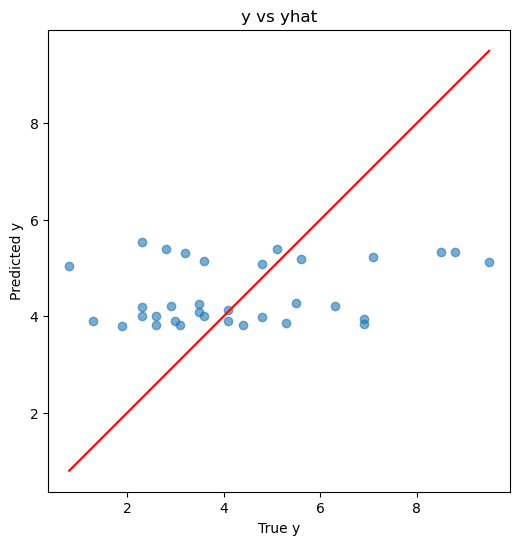

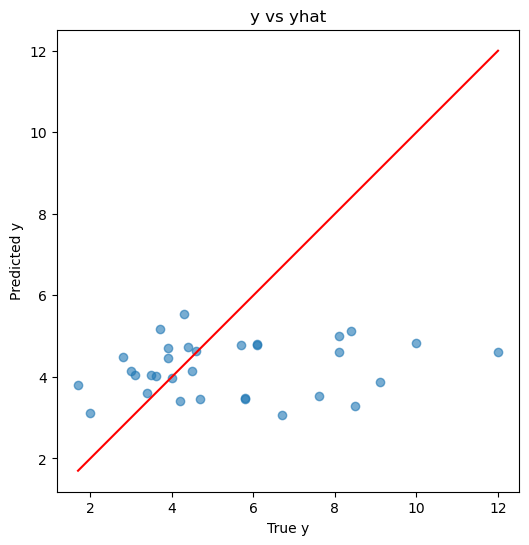

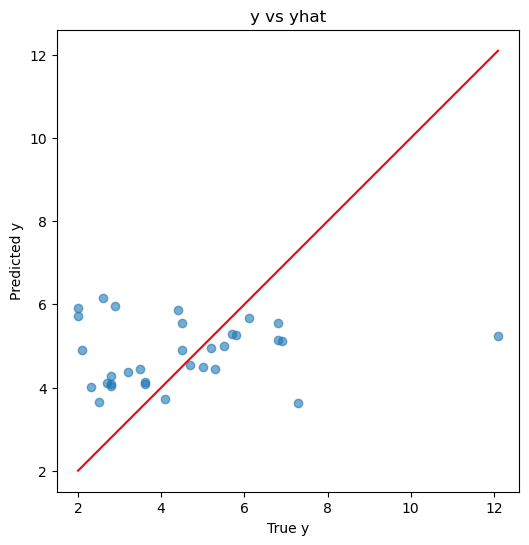

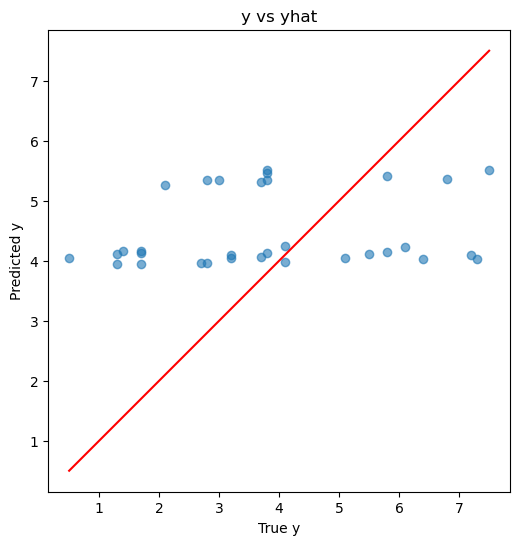

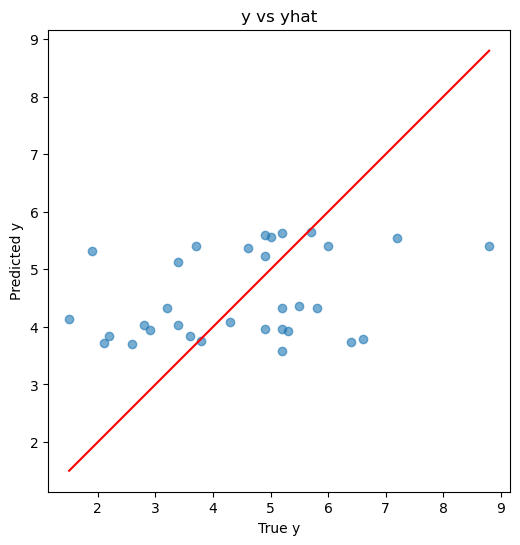

Baseline error_metric (5-fold CV): 4.509710368401417


In [75]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
kf = KFold(n_splits=5, shuffle=True)
cv_scores = []
models = []

for train_idx, test_idx in kf.split(X):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = clone(pipeline)
    model.fit(X_tr, y_tr)

    y_hat = model.predict(X_te)
    score = error_metric(y_te.values, y_hat, c=0)
    cv_scores.append(score)

    plot_y_yhat(y_te, y_hat)

    models.append(model)

print(f"Baseline error_metric ({kf.n_splits}-fold CV):", np.mean(cv_scores))

In [76]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2)

# Polynomial Regression
best_poly_model, best_degree, poly_cv_scores = select_polynomial_model(
    X_tr, y_tr,
    degrees=[1, 2, 3, 4, 5, 6, 7, 8],
    n_splits=5
)

print("="*60)
print("POLYNOMIAL REGRESSION - CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Best degree: {best_degree}")
print(f"\nCV scores by degree:")
for degree, score in poly_cv_scores.items():
    print(f"  Degree {degree}: {score:.6f}")
print("="*60)

y_pred_poly = best_poly_model.predict(X_te)

POLYNOMIAL REGRESSION - CROSS-VALIDATION RESULTS
Best degree: 1

CV scores by degree:
  Degree 1: 4.266753
  Degree 2: 4.466609
  Degree 3: 5.047944
  Degree 4: 9.759464
  Degree 5: 732.601020
  Degree 6: 2678872.791019
  Degree 7: 538237.611485
  Degree 8: 5139331.126883


In [77]:
best_degrees = []

for run in range(30):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2)

    best_model, best_degree, _ = select_polynomial_model(
        X_tr, y_tr,
        degrees=[1,2,3,4,5,6,7,8],
        n_splits=5,
        shuffle=True
    )
    best_degrees.append(best_degree)

Counter(best_degrees)

Counter({1: 27, 2: 3})

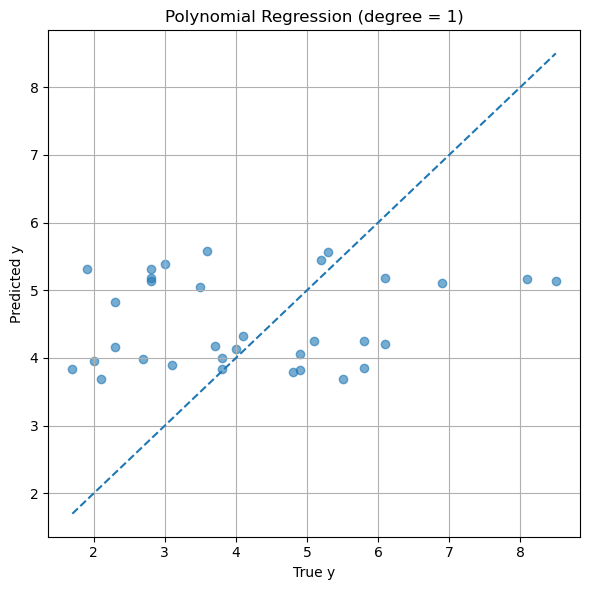

In [78]:
plot_y_vs_yhat(
    y_te,
    y_pred_poly,
    title=f"Polynomial Regression (degree = {best_degree})"
)

In [79]:
# k-Nearest Neighbors
best_knn_model, best_knn_params, knn_cv_scores = select_knn_model(
    X_tr, y_tr,
    k_list=[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
    weights_list=["uniform", "distance"],
    n_splits=5
)

print("="*60)
print("k-NEAREST NEIGHBORS - CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Best hyperparameters: {best_knn_params}")
print(f"\nCV scores by (k, weights):")
for params, score in knn_cv_scores.items():
    print(f"  k={params[0]}, weights={params[1]}: {score:.6f}")
print("="*60)

y_pred_knn = best_knn_model.predict(X_te)

k-NEAREST NEIGHBORS - CROSS-VALIDATION RESULTS
Best hyperparameters: {'k': 16, 'weights': 'uniform'}

CV scores by (k, weights):
  k=3, weights=uniform: 5.767847
  k=3, weights=distance: 7.064710
  k=4, weights=uniform: 5.839072
  k=4, weights=distance: 6.680453
  k=5, weights=uniform: 5.260537
  k=5, weights=distance: 6.508789
  k=6, weights=uniform: 5.152216
  k=6, weights=distance: 6.219803
  k=7, weights=uniform: 5.324825
  k=7, weights=distance: 5.489970
  k=8, weights=uniform: 4.972517
  k=8, weights=distance: 6.226579
  k=9, weights=uniform: 4.502617
  k=9, weights=distance: 6.149619
  k=10, weights=uniform: 5.032954
  k=10, weights=distance: 6.064898
  k=11, weights=uniform: 4.883854
  k=11, weights=distance: 5.450675
  k=12, weights=uniform: 4.651942
  k=12, weights=distance: 5.681017
  k=13, weights=uniform: 4.432371
  k=13, weights=distance: 5.864500
  k=14, weights=uniform: 4.559691
  k=14, weights=distance: 5.373230
  k=15, weights=uniform: 4.381174
  k=15, weights=distanc

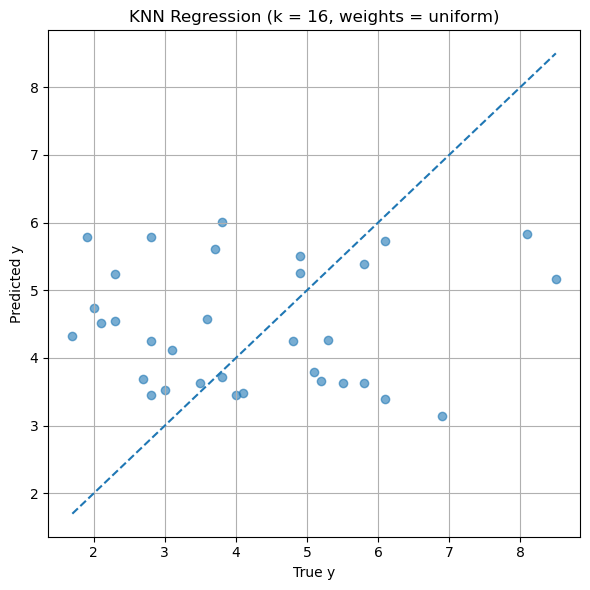

In [80]:
plot_y_vs_yhat(
    y_te,
    y_pred_knn,
    title=f"KNN Regression (k = {best_knn_params['k']}, weights = {best_knn_params['weights']})"
)

In [81]:
# Stability analysis: repeat hyperparameter selection multiple times
n_runs = 30   # number of repetitions
best_knn_list = []

for run in range(n_runs):
    X_tr_run, X_te_run, y_tr_run, y_te_run = train_test_split(
        X, y, test_size=0.2
    )

    best_knn_model_run, best_knn_params_run, knn_cv_scores_run = select_knn_model(
        X_tr_run, y_tr_run,
        k_list=[3,4,5,6,7,8,9,10,11,12,13,14,15,16],
        weights_list=["uniform", "distance"],
        n_splits=5
    )

    best_knn_list.append((best_knn_params_run["k"], best_knn_params_run["weights"]))

# Count how many times each (k, weights) combination is selected
knn_counter = Counter(best_knn_list)

print(f"\nFrequency of selected k-NN hyperparameters over {n_runs} runs:")
for params, freq in knn_counter.items():
    k_val, w_val = params
    print(f"(k={k_val}, weights='{w_val}') selected {freq} times")


Frequency of selected k-NN hyperparameters over 30 runs:
(k=13, weights='uniform') selected 5 times
(k=16, weights='uniform') selected 7 times
(k=8, weights='uniform') selected 1 times
(k=10, weights='distance') selected 1 times
(k=11, weights='uniform') selected 3 times
(k=12, weights='uniform') selected 6 times
(k=9, weights='uniform') selected 2 times
(k=10, weights='uniform') selected 3 times
(k=15, weights='uniform') selected 2 times


**TASK 2.2**

In [82]:
# Baseline model
baseline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

errors_baseline = evaluate_model_cv(baseline_model, X, y)

# Polynomial model (best already selected)
errors_poly = evaluate_model_cv(best_poly_model, X, y)

# KNN model (best already selected)
errors_knn = evaluate_model_cv(best_knn_model, X, y)


In [83]:
def summarize_errors(error_list):
    return {
        "min": np.min(error_list),
        "max": np.max(error_list),
        "mean": np.mean(error_list),
        "std": np.std(error_list)
    }

summary_df = pd.DataFrame({
    "Baseline (Linear)": summarize_errors(errors_baseline),
    f"Polynomial (deg={best_degree})": summarize_errors(errors_poly),
    f"KNN (k={best_knn_params['k']}, w={best_knn_params['weights']})": summarize_errors(errors_knn)
}).T

summary_df


,min,max,mean,std
Baseline (Linear),3.036053,5.629219,4.353691,1.012253
Polynomial (deg=1),2.746192,7.051856,4.410018,1.428086
"KNN (k=16, w=uniform)",2.373242,5.548987,4.325161,1.143691


In [84]:
#KNN
X_test = test[['Age', 'Gender', 'Stage', 'TreatmentType']]

y_test_pred = np.zeros(len(X_test))
for model in models:
    y_test_pred += best_knn_model.predict(X_test)
y_test_pred /= len(models)
submission_filename = "Nonlinear-submission-01.csv"

submission = pd.DataFrame({
    'id': test.index,
    0: y_test_pred
})

submission.to_csv(submission_filename, index=False)
print("Saved:", submission_filename)
submission.head()


Saved: Nonlinear-submission-01.csv


,id,0
0,0,5.92500
1,1,3.43750
2,2,3.41250
3,3,5.73125
4,4,3.25000


In [85]:
#Polynomial
X_test = test[['Age', 'Gender', 'Stage', 'TreatmentType']]

y_test_pred = np.zeros(len(X_test))
for model in models:
    y_test_pred += best_poly_model.predict(X_test)
y_test_pred /= len(models)
submission_filename = "Polynomial-submission-01.csv"

submission = pd.DataFrame({
    'id': test.index,
    0: y_test_pred
})

submission.to_csv(submission_filename, index=False)
print("Saved:", submission_filename)
submission.head()

Saved: Polynomial-submission-01.csv


,id,0
0,0,5.506412
1,1,4.139996
2,2,3.980594
3,3,5.295714
4,4,4.064226
